In [1]:
!pip install sentence-transformers

  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.8/570.8 kB 778.9 kB/s  0:00:00m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 2.2 MB/s  0:00:04m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 kB 3.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 3.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 3.5 MB/s  0:00:00 eta 0:00:01
Using cached filelock-3.25.2-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 3.8 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.6/801.6 kB 2.2 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 2.4 MB/s  0:00:0036m-:--:--
Using cached safetensor

In [4]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 286.4 kB/s  0:00:30m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 326.8 kB/s  0:00:15 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 257.1 kB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 232.8 kB/s  0:00:30 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [5]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10037.25it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
products = [
    {
        "name": "Lego Castle",
        "description": "A detailed building set that lets kids construct a medieval castle with towers, knights, and imaginative storytelling elements."
    },
    {
        "name": "Wooden Blocks",
        "description": "A set of natural wooden blocks designed to improve creativity and motor skills through stacking, building, and open-ended play."
    },
    {
        "name": "Action Figure",
        "description": "A poseable superhero action figure with accessories, perfect for role-playing, battles, and imaginative adventures."
    }
]

In [7]:
descriptions = [p["description"] for p in products]
embeddings = model.encode(descriptions)

In [8]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [9]:
for i in range(len(products)):
    for j in range(i + 1, len(products)):
        sim = cosine_similarity(embeddings[i], embeddings[j])
        print(f"{products[i]['name']} vs {products[j]['name']} → {sim:.4f}")

Lego Castle vs Wooden Blocks → 0.4347
Lego Castle vs Action Figure → 0.2885
Wooden Blocks vs Action Figure → 0.1852


In [10]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

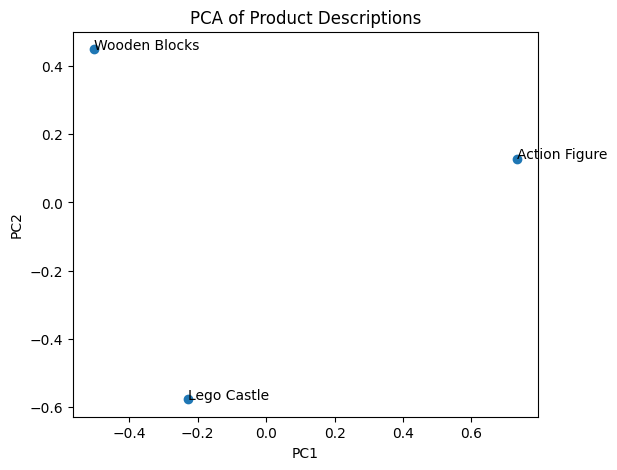

In [11]:
plt.figure(figsize=(6, 5))

x = reduced[:, 0]
y = reduced[:, 1]

plt.scatter(x, y)

for i, p in enumerate(products):
    plt.text(x[i], y[i], p["name"])

plt.title("PCA of Product Descriptions")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()